<a href="https://colab.research.google.com/github/caioabrahao/Deep-Learning---Avalia-o-2/blob/main/IAAM_CIFAR10_Complete_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# IAAM - Avaliação Prática 2
## Pipeline Completo CIFAR-10 com PyTorch

Este notebook implementa:
- Carregamento do dataset CIFAR-10
- Exploração dos dados
- Pré-processamento e Data Augmentation
- Divisão treino/validação/teste
- Construção de uma CNN
- Treinamento com validação
- Early Stopping
- Scheduler de Learning Rate
- Avaliação final
- Matriz de confusão
- Classification Report


In [1]:

# Imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
from PIL import Image


In [2]:

# Seed para reprodutibilidade

SEED = 2025

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cpu


In [3]:

# Classes do CIFAR-10

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


In [4]:

# Transformação básica

transform_basic = transforms.ToTensor()

# Dataset original

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_basic
)

# Estrutura dfgen

dfgen = {
    "features": dataset.data,
    "labels": dataset.targets
}

print("Shape das imagens:", dfgen["features"].shape)
print("Quantidade de labels:", len(dfgen["labels"]))


100%|██████████| 170M/170M [00:03<00:00, 45.2MB/s]


Shape das imagens: (50000, 32, 32, 3)
Quantidade de labels: 50000


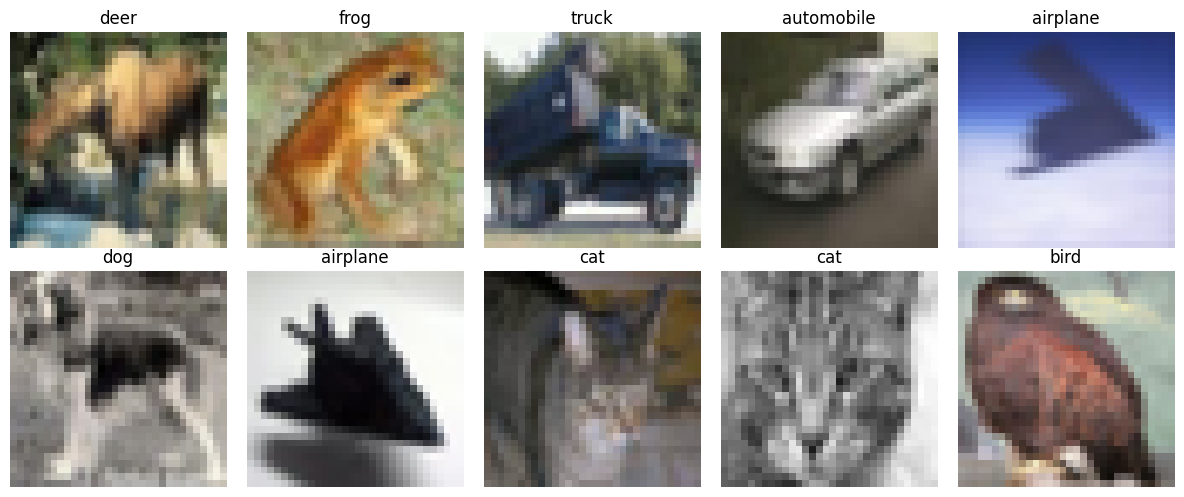

In [5]:

# Mostrar 10 imagens aleatórias

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for ax in axes.flatten():
    idx = random.randint(0, len(dataset)-1)

    image, label = dataset[idx]

    image = image.permute(1,2,0)

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()


In [6]:

# Contagem por classe

counter = Counter(dataset.targets)

for idx, count in counter.items():
    print(f"{classes[idx]}: {count}")


frog: 5000
truck: 5000
deer: 5000
automobile: 5000
bird: 5000
horse: 5000
ship: 5000
cat: 5000
dog: 5000
airplane: 5000


In [7]:

# Data augmentation

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])


In [8]:

# Carregar conjuntos treino e teste

train_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True
)

test_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True
)

# Concatenar tudo

X = np.concatenate([train_full.data, test_full.data])
y = np.concatenate([train_full.targets, test_full.targets])

print("Dataset total:", X.shape)


Dataset total: (60000, 32, 32, 3)


In [9]:

# Divisão treino/validação/teste
# 70% treino
# 15% validação
# 15% teste

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))


Treino: 42000
Validação: 9000
Teste: 9000


In [10]:

# Classe customizada

class CIFARCustom(Dataset):

    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        image = self.X[idx]
        label = self.y[idx]

        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label


In [11]:

# Criar datasets

train_dataset = CIFARCustom(X_train, y_train, train_transform)
val_dataset = CIFARCustom(X_val, y_val, test_transform)
test_dataset = CIFARCustom(X_test, y_test, test_transform)

# DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [12]:

# Modelo CNN

class clfgen(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Dropout(0.3),

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

model = clfgen().to(device)

print(model)


clfgen(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    

In [13]:

# Loss e Otimizador

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=3,
    factor=0.5
)


In [14]:

# Função para calcular accuracy

def calculate_accuracy(loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


In [ ]:

# Treinamento

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0

patience = 10
counter = 0

EPOCHS = 50

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # Validação

    model.eval()

    val_running_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)

    train_acc = calculate_accuracy(train_loader)
    val_acc = calculate_accuracy(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}%")
    print("-" * 40)

    # Salvar melhor modelo

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        counter = 0

    else:
        counter += 1

    # Early stopping

    if counter >= patience:
        print("Early stopping ativado.")
        break


Epoch 1/50
Train Loss: 1.7022
Val Loss: 1.2772
Train Acc: 49.86%
Val Acc: 52.73%
----------------------------------------
Epoch 2/50
Train Loss: 1.3895
Val Loss: 1.2686
Train Acc: 52.94%
Val Acc: 56.67%
----------------------------------------


In [ ]:

# Curva de Accuracy

plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()


In [ ]:

# Curva de Loss

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()


In [ ]:

# Carregar melhor modelo

model.load_state_dict(torch.load("best_model.pth"))

model.eval()


In [ ]:

# Avaliação no conjunto de teste

y_true = []
y_pred = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * correct / total

print(f"Accuracy de teste: {test_acc:.2f}%")


In [ ]:

# Matriz de confusão

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()


In [ ]:

# Classification Report

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))



# Discussão dos Resultados

## Possíveis confusões entre classes

As classes mais confundidas normalmente são:
- cat ↔ dog
- deer ↔ horse
- automobile ↔ truck

Isso ocorre porque:
- As imagens possuem apenas 32x32 pixels.
- Algumas classes possuem características visuais semelhantes.
- Há pouca resolução para detalhes finos.

## Papel da Validação

A validação foi importante para:
- Escolher o melhor modelo.
- Detectar overfitting.
- Acionar early stopping.
- Ajustar o learning rate.

## Papel do Data Augmentation

O augmentation ajudou o modelo a:
- Generalizar melhor.
- Reduzir overfitting.
- Aprender padrões mais robustos.
